# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## 1.2 Функции

In [4]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    # Конвертируем дату если нужно
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    
    # Создаем один большой график
    plt.figure(figsize=(16, 8))
    
    # График реальных и предсказанных изменений
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    # Нулевая линия
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Настройки графика
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()

In [5]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse, 
        'r2': r2,
        'direction_accuracy': direction_accuracy
    }

In [6]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    model = RandomForestRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Random Forest - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_dt(X_train, X_test, y_train):
    """Обучает и предсказывает Decision Tree для регрессии"""
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['squared_error', 'friedman_mse']
    }
    
    model = DecisionTreeRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Decision Tree - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_linear_reg(X_train, X_test, y_train):
    """Обучает и предсказывает Linear Regression с нормализацией"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'fit_intercept': [True, False]
    }
    
    model = LinearRegression()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Linear Regression - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test_scaled)
    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [100, 200, 500]
    }
    
    model = CatBoostRegressor(verbose=False, random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"CatBoost - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

In [7]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

## 2.0 Список тикеров

In [10]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Чтение

In [12]:
data_SBER = pd.read_csv("../../../data/stock_features_data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("../../../data/stock_features_data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("../../../data/stock_features_data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("../../../data/stock_features_data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("../../../data/stock_features_data/stocks_features_ROSN.csv")
data_ROSN.head(2)

,begin,close,MA_90,RSI_14,RSI_90,MOM_10,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD_SIGNAL,MACD_HISTOGRAM,target_price_change,target_class
0,2022-05-31 18:00:00,377.00,385.952778,41.700213,46.109636,-6.102117,6.815141,0.177819,0.184228,0.180549,1.622548,-2.115281,-2.771883,L
1,2022-06-01 10:00:00,378.35,385.708333,43.536971,46.522581,-3.703232,6.960488,0.153935,0.177697,0.770980,1.125999,-1.986196,-1.361174,L


In [24]:
data_ROSN.begin

0       2022-05-31 18:00:00
1       2022-06-01 10:00:00
2       2022-06-01 12:00:00
3       2022-06-01 14:00:00
4       2022-06-01 16:00:00
               ...         
4279    2025-09-30 10:00:00
4280    2025-09-30 12:00:00
4281    2025-09-30 14:00:00
4282    2025-09-30 16:00:00
4283    2025-09-30 18:00:00
Name: begin, Length: 4284, dtype: object

## 2.2 Удаление лишних признаков

In [16]:
# Для SBER
part_SBER = data_SBER[['begin', 'close', 'target_class']]
data_SBER.drop(['close', 'target_class'], axis=1, inplace=True)

# Для TCSG
part_TCSG = data_TCSG[['begin', 'close', 'target_class']]
data_TCSG.drop(['close', 'target_class'], axis=1, inplace=True)

# Для GAZP
part_GAZP = data_GAZP[['begin', 'close', 'target_class']]
data_GAZP.drop(['close', 'target_class'], axis=1, inplace=True)

# Для LKOH
part_LKOH = data_LKOH[['begin', 'close', 'target_class']]
data_LKOH.drop(['close', 'target_class'], axis=1, inplace=True)

# Для ROSN
part_ROSN = data_ROSN[['begin', 'close', 'target_class']]
data_ROSN.drop(['close', 'target_class'], axis=1, inplace=True)

## 2.3 Разделение на train/test

In [18]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-05-31 18:00:00 - 2025-03-11 14:00:00 (3427 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2024-06-03 10:00:00 (2367 samples)
Test:  2024-06-03 12:00:00 - 2024-11-20 18:00:00 (592 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-03-11 14:00:00 (3427 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-03-11 14:00:00 (3427 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-03-11 14:00:00 (3427 samples)
Test:  2025-03-11 16:00:00 - 2025-09-30 18:00:00 (857 samples)
Признаков: 10


# 3 Обучение моделей с подбором гиперпараметров

## 3.1 Дерево решений

### 3.1.1 Сбер

In [22]:
y_pred_SBER = train_predict_dt(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 МОДЕЛЬ: 
MAE: 2.6561%
RMSE: 3.3333%
R²: -0.4490
Accuracy направления: 0.4912


{'mae': 2.6560966284764973,
 'rmse': 3.3332702172668607,
 'r2': -0.4490429614082063,
 'direction_accuracy': 0.4912485414235706}

### 3.1.2 Тиньк

In [24]:
y_pred_TCSG = train_predict_dt(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 3.7348%
RMSE: 4.8433%
R²: -0.0214
Accuracy направления: 0.5963


{'mae': 3.7348302874619352,
 'rmse': 4.84331769944399,
 'r2': -0.021414045582956343,
 'direction_accuracy': 0.5962837837837838}

### 3.1.3 Газпром

In [26]:
y_pred_GAZP = train_predict_dt(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 5.0659%
RMSE: 6.4070%
R²: -0.1614
Accuracy направления: 0.6079


{'mae': 5.065885959422821,
 'rmse': 6.406966052524934,
 'r2': -0.16136584521553177,
 'direction_accuracy': 0.6079346557759626}

### 3.1.4 Лукойл

In [28]:
y_pred_LKOH = train_predict_dt(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 3.3266%
RMSE: 4.1812%
R²: -0.3891
Accuracy направления: 0.4994


{'mae': 3.326592725062546,
 'rmse': 4.181205234102082,
 'r2': -0.38911544996233705,
 'direction_accuracy': 0.49941656942823803}

### 3.1.5 Роснефть

In [30]:
y_pred_ROSN = train_predict_dt(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

📊 МОДЕЛЬ: 
MAE: 5.9056%
RMSE: 7.0320%
R²: -1.4977
Accuracy направления: 0.5438


{'mae': 5.905607727216033,
 'rmse': 7.0319775085680245,
 'r2': -1.497690708807744,
 'direction_accuracy': 0.543757292882147}

## Вывод

Кажется, MAE достаточно большая

## 3.2 Регрессия

### 3.2.1 Сбер

In [35]:
y_pred_SBER = train_predict_linear_reg(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 2.3672%
RMSE: 2.9339%
R²: -0.1226
Accuracy направления: 0.5158


{'mae': 2.367174503894134,
 'rmse': 2.9339273082333417,
 'r2': -0.12263587577737578,
 'direction_accuracy': 0.5157526254375729}

### 3.2.2 Тиньк

In [37]:
y_pred_TCSG = train_predict_linear_reg(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 3.9208%
RMSE: 5.0267%
R²: -0.1002
Accuracy направления: 0.4426


{'mae': 3.920754624027114,
 'rmse': 5.026672916850483,
 'r2': -0.10021399203209569,
 'direction_accuracy': 0.44256756756756754}

### 3.2.3 Газпром

In [39]:
y_pred_GAZP = train_predict_linear_reg(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 5.2179%
RMSE: 6.2516%
R²: -0.1057
Accuracy направления: 0.4667


{'mae': 5.217944653403911,
 'rmse': 6.251555174369449,
 'r2': -0.10570771755839714,
 'direction_accuracy': 0.46674445740956827}

### 3.2.4 Лукойл

In [41]:
y_pred_LKOH = train_predict_linear_reg(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 2.7737%
RMSE: 3.4846%
R²: 0.0352
Accuracy направления: 0.6044


{'mae': 2.773682983164515,
 'rmse': 3.4846243466107687,
 'r2': 0.0351777635527194,
 'direction_accuracy': 0.6044340723453909}

### 3.2.5 Роснефть

In [43]:
y_pred_ROSN = train_predict_linear_reg(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 3.7700%
RMSE: 4.6411%
R²: -0.0880
Accuracy направления: 0.4936


{'mae': 3.7700369755228986,
 'rmse': 4.64109155299955,
 'r2': -0.08798769514347438,
 'direction_accuracy': 0.4935822637106184}

## Вывод

Результаты лучше чем у дерева

## 3.3 Вот он, лес

### 3.3.1 Сбер

In [52]:
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

📊 МОДЕЛЬ: 
MAE: 2.4431%
RMSE: 3.0354%
R²: -0.2016
Accuracy направления: 0.5321


{'mae': 2.443082502971086,
 'rmse': 3.035375178954789,
 'r2': -0.20161398653932316,
 'direction_accuracy': 0.5320886814469078}

### 3.3.2 Тиньк

In [55]:
y_pred_TCSG = train_predict_rf(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 4.4003%
RMSE: 5.7748%
R²: -0.4521
Accuracy направления: 0.4730


{'mae': 4.400304952095433,
 'rmse': 5.774799635521811,
 'r2': -0.45207734919508913,
 'direction_accuracy': 0.47297297297297297}

### 3.3.3 Газпром

In [60]:
y_pred_GAZP = train_predict_rf(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 5.1083%
RMSE: 6.6386%
R²: -0.2469
Accuracy направления: 0.4947


{'mae': 5.108288459172111,
 'rmse': 6.6386493119118635,
 'r2': -0.24687712926693028,
 'direction_accuracy': 0.49474912485414235}

### 3.3.4 Лукойл

In [63]:
y_pred_LKOH = train_predict_rf(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 3.5188%
RMSE: 4.3747%
R²: -0.5207
Accuracy направления: 0.4644


{'mae': 3.5187512008122184,
 'rmse': 4.374708264355947,
 'r2': -0.5206650483231843,
 'direction_accuracy': 0.4644107351225204}

### 3.3.5 Роснефть

In [65]:
y_pred_ROSN = train_predict_rf(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

📊 МОДЕЛЬ: 
MAE: 4.5863%
RMSE: 5.6731%
R²: -0.6256
Accuracy направления: 0.5018


{'mae': 4.586301644543559,
 'rmse': 5.6730514700998285,
 'r2': -0.6256129861168125,
 'direction_accuracy': 0.5017502917152858}

## Вывод

Качесто где-то лучше чем у регрессии а где-то хуже

## 3.4 Бустинг

### 3.4.1 Сбер

In [70]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.2797%
RMSE: 2.7896%
R²: -0.0149
Accuracy направления: 0.4901


{'mae': 2.279691040318903,
 'rmse': 2.789626567625175,
 'r2': -0.01492128071658927,
 'direction_accuracy': 0.49008168028004667}

### 3.4.2 Тиньк

In [72]:
y_pred_TCSG = train_predict_catboost(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.8693%
RMSE: 4.9980%
R²: -0.0877
Accuracy направления: 0.4088


{'mae': 3.869267352335807,
 'rmse': 4.997960367816026,
 'r2': -0.08768095985907265,
 'direction_accuracy': 0.40878378378378377}

### 3.4.3 Газпром

In [74]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

CatBoost - лучшие параметры: {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.8854%
RMSE: 6.0842%
R²: -0.0473
Accuracy направления: 0.5834


{'mae': 4.885382907727858,
 'rmse': 6.084165695466093,
 'r2': -0.04728834409148375,
 'direction_accuracy': 0.5834305717619603}

### 3.4.4 Лукойл

In [76]:
y_pred_LKOH = train_predict_catboost(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.9925%
RMSE: 3.7581%
R²: -0.1222
Accuracy направления: 0.4959


{'mae': 2.9924812222992228,
 'rmse': 3.758122660739855,
 'r2': -0.12221810912592823,
 'direction_accuracy': 0.4959159859976663}

### 3.4.5 Роснефть

In [78]:
y_pred_ROSN = train_predict_catboost(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.9168%
RMSE: 4.8092%
R²: -0.1682
Accuracy направления: 0.5123


{'mae': 3.916839582161037,
 'rmse': 4.809177200602996,
 'r2': -0.16822170611495046,
 'direction_accuracy': 0.5122520420070011}

## Вывод

На всех акциях кроме Газпрома качество предсказаний улучшилось

Таким образом лучше всего работает опять бустинг

# 4 Визуализация резульататов

## 4.1 Сбер

In [84]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
df_SBER_pred.head()

,target_price_change,begin,close,predict
3427,2.705739,2025-03-11 16:00:00,320.43,0.474075
3428,2.488836,2025-03-11 18:00:00,320.23,0.445439
3429,2.340103,2025-03-12 10:00:00,317.08,0.405833
3430,1.856864,2025-03-12 12:00:00,317.74,0.391973
3431,1.830642,2025-03-12 14:00:00,319.56,0.376006


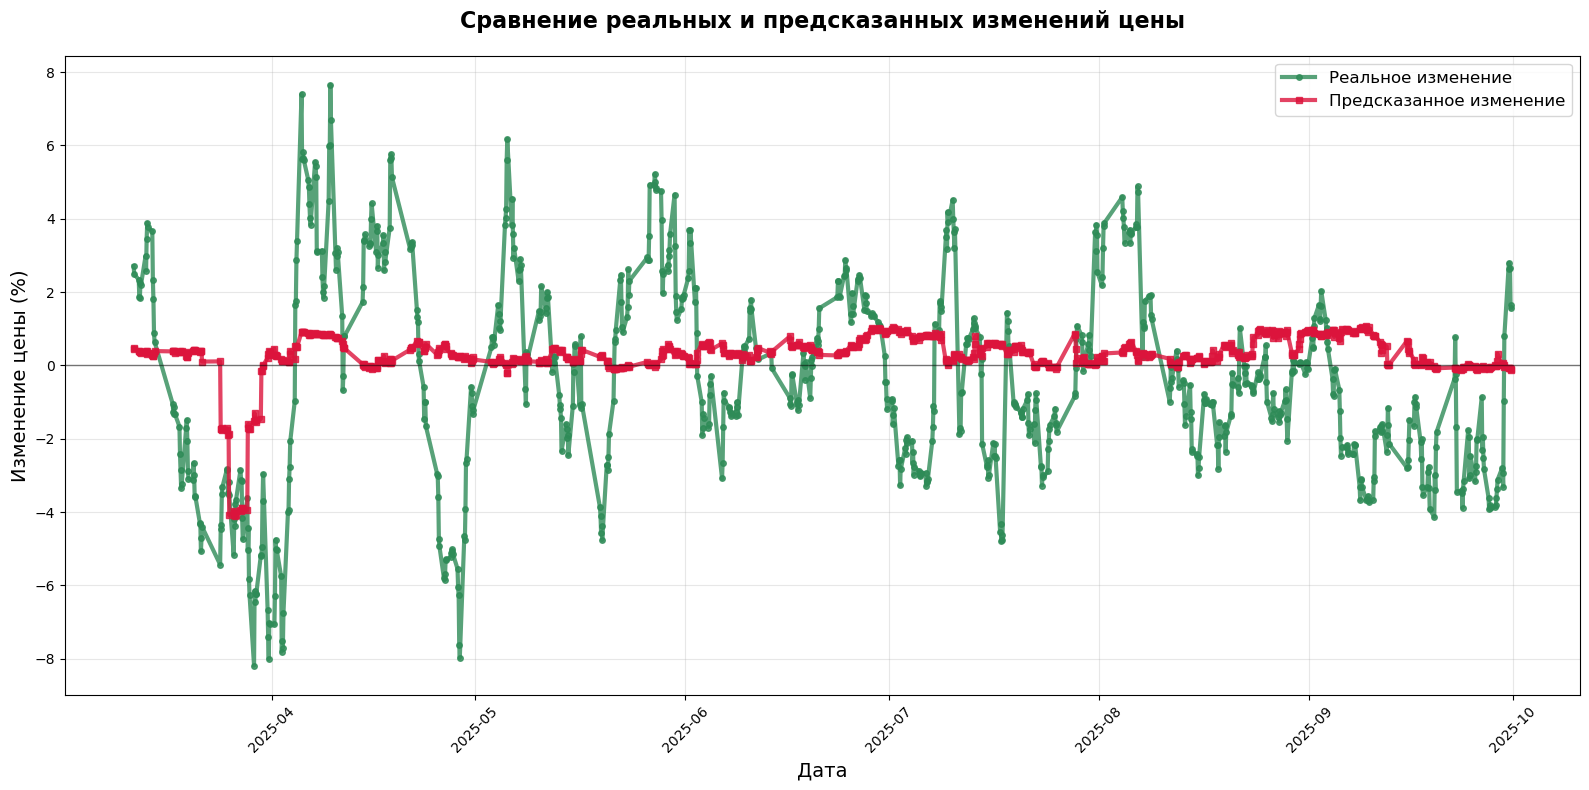

In [85]:
visualize_predictions_comparison(df_SBER_pred)

## 4.2 Газпром

In [87]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
df_GAZP_pred.head()

,target_price_change,begin,close,predict
3427,1.570466,2025-03-11 16:00:00,170.65,-0.532907
3428,1.062643,2025-03-11 18:00:00,170.33,-0.488189
3429,-0.556905,2025-03-12 10:00:00,168.79,-0.370107
3430,-1.360746,2025-03-12 12:00:00,168.29,-0.405465
3431,-0.041430,2025-03-12 14:00:00,168.96,-0.339457


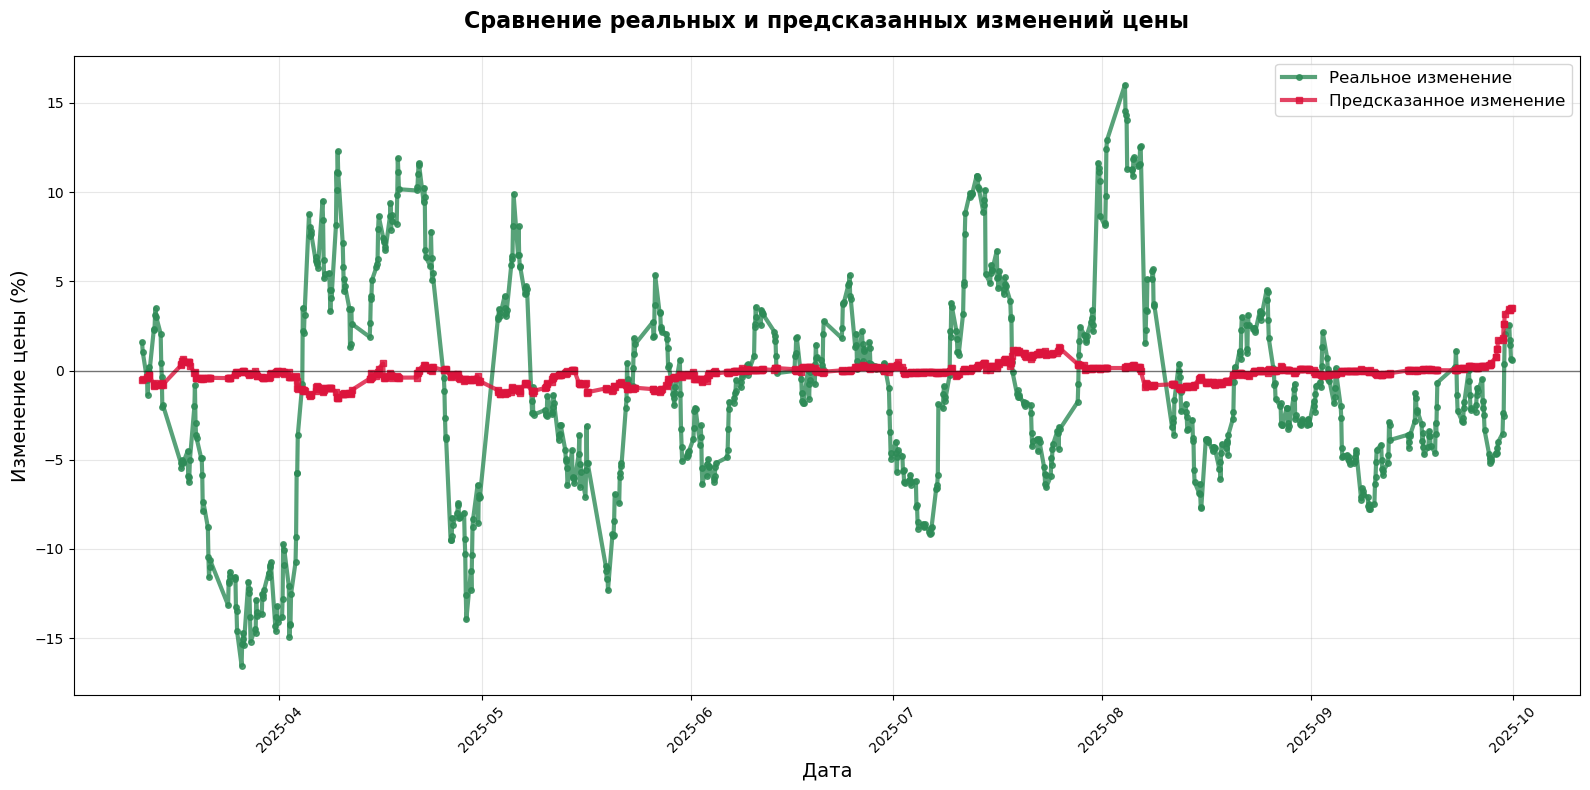

In [88]:
visualize_predictions_comparison(df_GAZP_pred)